In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# importing data
challan = pd.read_csv('./dataset/echallan_daily_data.csv')
challan

,date,totalChallan,disposedChallan,pendingChallan,pendingAmount,disposedAmount,totalAmount,pendingCourt,disposedCourt,totalCourt
0,2015-01-01,120,29,91,588600,116860,705460,1,0,1
1,2015-01-02,162,39,123,663350,281425,944775,1,1,2
2,2015-01-03,122,34,88,596900,286950,883850,4,1,5
3,2015-01-04,116,27,89,967350,301600,1268950,3,2,5
4,2015-01-05,162,28,134,877654,103000,980654,2,0,2
...,...,...,...,...,...,...,...,...,...,...
4056,2026-02-09,242251,33045,209206,399248914,72117659,471366573,13240,107,13347
4057,2026-02-10,235459,30908,204551,409291982,75390316,484682298,13867,86,13953
4058,2026-02-11,234315,31543,202772,405939091,73253910,479193001,13760,44,13804
4059,2026-02-12,185594,24278,161316,307489891,54353608,361843499,8896,16,8912


In [129]:
# 1. structure check
print(f"Challan Dataset Shape: {challan.shape}\n")
print(f"Challan Dataset Columns: {challan.columns}\n")
print(f"Challan Dataset No. of Dimensions: {challan.ndim}\n")
print(f"Categorical data columns: {challan.select_dtypes(include=['category', 'object', 'bool', 'str']).columns}\n")
challan.info()

Challan Dataset Shape: (4061, 13)

Challan Dataset Columns: Index(['date', 'totalChallan', 'disposedChallan', 'pendingChallan',
       'pendingAmount', 'disposedAmount', 'totalAmount', 'pendingCourt',
       'disposedCourt', 'totalCourt', 'year', 'disposalRate', 'courtRate'],
      dtype='str')

Challan Dataset No. of Dimensions: 2

Categorical data columns: Index([], dtype='str')

<class 'pandas.DataFrame'>
RangeIndex: 4061 entries, 0 to 4060
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             4061 non-null   datetime64[us]
 1   totalChallan     4061 non-null   int64         
 2   disposedChallan  4061 non-null   int64         
 3   pendingChallan   4061 non-null   int64         
 4   pendingAmount    4061 non-null   int64         
 5   disposedAmount   4061 non-null   int64         
 6   totalAmount      4061 non-null   int64         
 7   pendingCourt     4061 non-null   int6

In [9]:
# 2. checking for missing values
challan.isnull().sum()

date               0
totalChallan       0
disposedChallan    0
pendingChallan     0
pendingAmount      0
disposedAmount     0
totalAmount        0
pendingCourt       0
disposedCourt      0
totalCourt         0
dtype: int64

In [11]:
# 3. Duplicates
print("Duplicated Data Says True! \n")
print(f"{challan.duplicated()}\n")
print(f"Total number of duplicated rows: {challan.duplicated().sum()}")

Duplicated Data Says True! 

0       False
1       False
2       False
3       False
4       False
        ...  
4056    False
4057    False
4058    False
4059    False
4060    False
Length: 4061, dtype: bool

Total number of duplicated rows: 0


In [171]:
# 4. Summary statistics
print("Data Statistics : \n")
print(challan.describe(), end="\n\n")
print("Including Objects Only")
print(challan.describe(include='object'))

Data Statistics : 

                             date   totalChallan  disposedChallan  \
count                        4061    4061.000000      4061.000000   
mean   2020-07-23 14:15:16.621521  102564.295986     39190.895100   
min           2015-01-01 00:00:00      10.000000         6.000000   
25%           2017-10-12 00:00:00    1864.000000      1032.000000   
50%           2020-07-24 00:00:00  104931.000000     47012.000000   
75%           2023-05-05 00:00:00  174420.000000     67133.000000   
max           2026-02-13 00:00:00  332710.000000     96645.000000   
std                           NaN   94274.309905     30766.668065   

       pendingChallan  pendingAmount  disposedAmount   totalAmount  \
count     4061.000000   4.061000e+03    4.061000e+03  4.061000e+03   
mean     63373.400886   9.998178e+07    5.655994e+07  1.565417e+08   
min          3.000000   2.040000e+04    6.700000e+03  5.440000e+04   
25%       1131.000000   1.765850e+06    5.127580e+06  7.183220e+06   
50%     

C:\Users\keval\AppData\Local\Temp\ipykernel_2656\224963630.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(challan.describe(include='object'))


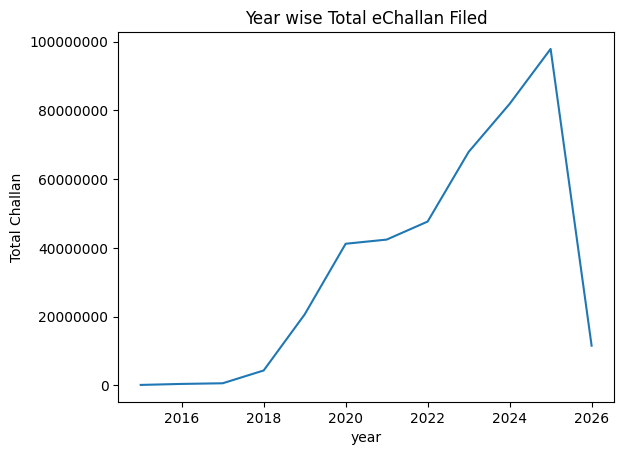

In [ ]:
# 5. Analysis

# 5.1 Year wise challan 
challan['date'] = pd.to_datetime(challan['date'])
challan['year'] = challan['date'].dt.year

yearly = challan.groupby("year").sum(numeric_only=True).reset_index()
lp = sns.lineplot(data=yearly, x="year", y="totalChallan", markers="o")
lp.ticklabel_format(style="plain", axis="y")
plt.title("Year wise Total eChallan Filed")
plt.ylabel("Total Challan")
plt.show()

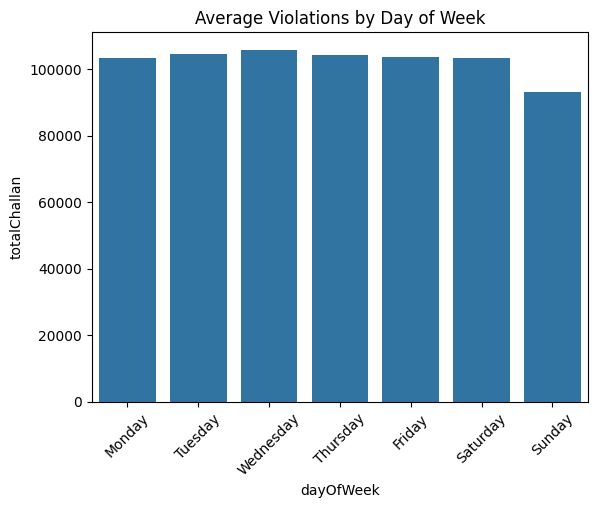

In [ ]:
# 5.2 Which day in a week has the highest violations
challan["date"] = pd.to_datetime(challan["date"])
challan['dayOfWeek'] = challan['date'].dt.day_name()
ord = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_avg = challan.groupby('dayOfWeek')["totalChallan"].mean().reset_index()
sns.barplot(data=day_avg, x="dayOfWeek", y='totalChallan', order=ord)
plt.title("Average Violations by Day of Week")
plt.xticks(rotation=45)
plt.show()

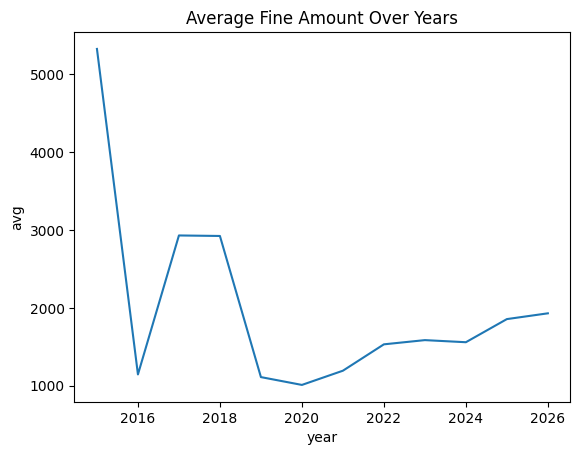

In [159]:
# 5.3 Average Fine Amount Over Time
challan["date"] = pd.to_datetime(challan["date"])
challan['year'] = challan['date'].dt.year
challan['avg'] = challan['totalAmount'] / challan['totalChallan']
avg_challan_per_year = challan.groupby('year')['avg'].mean().reset_index()
sns.lineplot(data=avg_challan_per_year, x="year", y="avg", markers="*")
plt.title("Average Fine Amount Over Years")
plt.show()

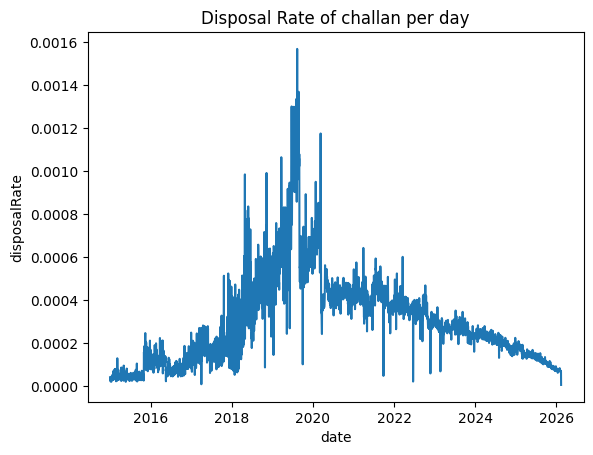

In [122]:
# 5.4 Disposal Efficiency Analysis
challan['disposalRate'] = challan['disposedChallan'] / challan['totalAmount']
challan['disposalRate']
sns.lineplot(data=challan, x="date", y="disposalRate")
plt.title("Disposal Rate of challan per day")
plt.show()

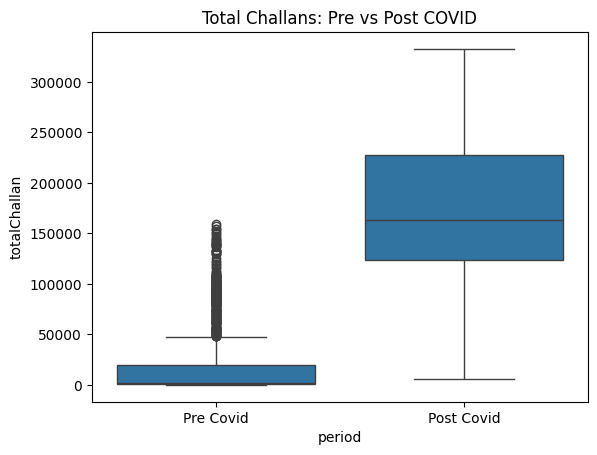

In [ ]:
# 5.5 COVID Impact Analysis
challan["period"] = challan["date"].apply(
    lambda x: "Pre Covid" if x < pd.Timestamp("2020-03-01") else "Post Covid"
)
sns.boxplot(data=challan, x="period", y="totalChallan")
plt.title("Total Challans: Pre vs Post COVID")
plt.show()

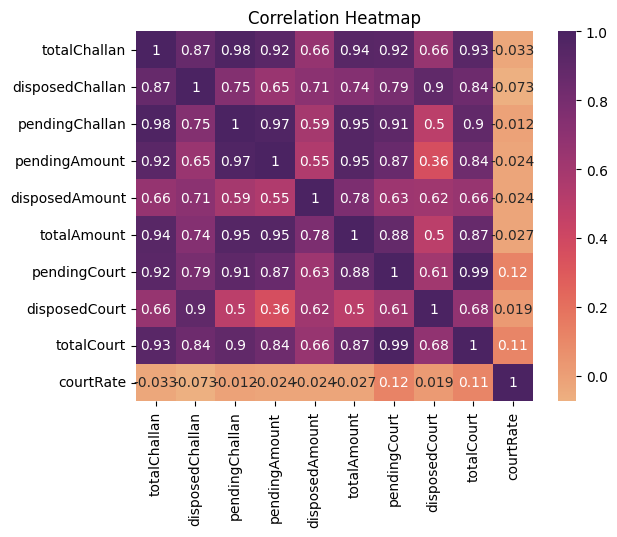

In [137]:
# 6. Correlation check
corr_matrix = challan.select_dtypes(include="number").corr()

sns.heatmap(data=corr_matrix, annot=True, cmap="flare")
plt.title("Correlation Heatmap")
plt.show()

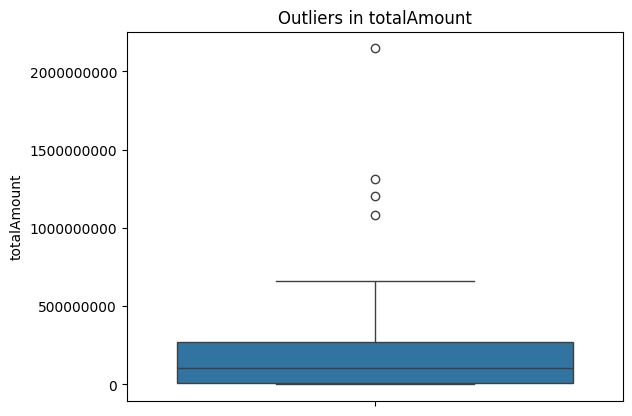

In [ ]:
# 7. Outlier detection
bx = sns.boxplot(data=challan, y="totalAmount")
bx.ticklabel_format(style='plain', axis="y")
plt.title("Outliers in totalAmount")
plt.show()

In [ ]:
# 8. Skewness check
challan.select_dtypes(include='number').skew()

totalChallan        0.446483
disposedChallan    -0.133945
pendingChallan      0.987948
pendingAmount       1.448071
disposedAmount     11.503952
totalAmount         1.442754
pendingCourt        0.967327
disposedCourt       0.124632
totalCourt          0.727263
dtype: float64

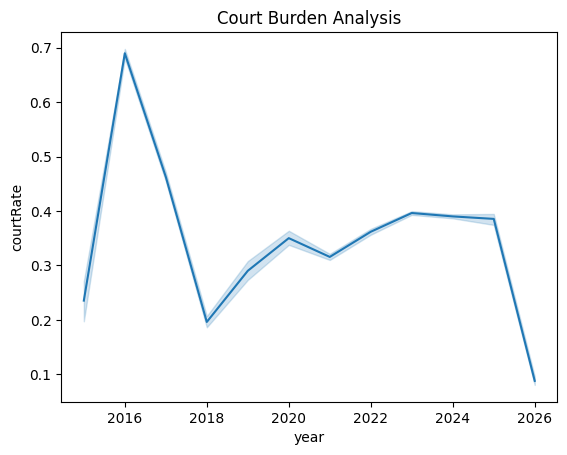

In [ ]:
# 9. Feature insights
# Court Burden Analysis : Showing dependency or involvement of court in challan cases

challan['courtRate'] = challan['totalCourt'] / challan['totalChallan']
challan['date'] = pd.to_datetime(challan['date'])
challan['year'] = challan['date'].dt.year
# sns.lineplot(data=challan, x="date", y="courtRate")
sns.lineplot(data=challan, x="year", y="courtRate")
plt.title("Court Burden Analysis")

# The below block was not working as court burden analysis was blank without any kind of error

# challan = pd.read_csv('./dataset/echallan_daily_data.csv')
# challan['courtRate'] = challan['totalCourt'] / challan['totalChallan']
# fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# sns.lineplot(data=challan, x="date", y="courtRate")
# axes[0].set_title("Court Burden Analysis")
# sns.lineplot(data=challan, x="date", y="totalChallan")
# axes[1].set_title("Total Challan trend")
# plt.tight_layout()
plt.show()